In [1]:
from pathlib import Path
import os
import sys
from typing import Dict, Sequence, Optional

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl

CWD = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [CWD, *CWD.parents, CWD / "allhands_meeting" / "pcmdi_package"]:
    if (candidate / "scripts").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate pcmdi_package/scripts from the current working directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from metrics_group_merger import PCMDIRun


In [2]:
class ENSOPatternMapPlotter:
    """
    Plot ENSO diagnostics as Hovmöller diagrams (y_dim vs longitude) for:
      - reference (obs)
      - one or more model fields

    Expects a data_dict with keys like:
      data_dict["reference"] : (y_dim, lon)
      data_dict["v3.LR.CPL"] : (y_dim, lon) or (member, y_dim, lon)

    For the ENSO seasonality metric, y_dim = 'months', lon = 'longitude'.
    """

    def __init__(
        self,
        data_dict: Dict[str, xr.DataArray],
        fig_dir: str,
        plot_dict: Dict[str, dict],
        group_order: Sequence[str] = ("v3.LR.CPL", "v3.HR.CPL", "v4P.CPL", "v4P.AMIP"),
        obs_key: str = "reference",
        lat_name: str = "latitude",      # here: vertical axis (e.g., 'months')
        lon_name: str = "longitude_a",   # here: horizontal axis (e.g., 'longitude')
    ):
        """
        Parameters
        ----------
        data_dict : dict
            Mapping from group key to DataArray.
            Must contain obs_key and all groups in group_order.
        fig_dir : str
            Directory where figures are saved.
        plot_dict : dict
            Styling information keyed by group name, e.g.
              {
                "reference": {"label": "ERA-Interim (Ref)"},
                "v3.LR.CPL": {"label": "v3.LR.CPL"},
                "v3.HR.CPL": {"label": "v3.HR.CPL"},
              }
        group_order : sequence
            Model groups to plot after the reference.
        obs_key : str
            Key in data_dict for the observational reference.
        lat_name, lon_name : str
            Names of vertical and horizontal coordinates in the DataArrays.
            For Hovmöller ENSO seasonality: lat_name='months', lon_name='longitude'.
        """
        self.data_dict   = data_dict
        self.fig_dir     = fig_dir
        self.plot_dict   = plot_dict
        self.group_order = tuple(group_order)
        self.obs_key     = obs_key
        self.lat_name    = lat_name
        self.lon_name    = lon_name

        # Build mean & spread fields
        self.mean_maps   = self._build_mean_maps()
        self.spread_maps = self._build_spread_maps()

    # -------------------------------------------------------------------------
    # Internal helpers for mean / spread
    # -------------------------------------------------------------------------
    def _build_mean_maps(self) -> Dict[str, xr.DataArray]:
        """Return dict of mean fields (lat_name, lon_name) for each key."""
        mean_maps = {}

        # ---- reference ----
        if self.obs_key not in self.data_dict:
            raise ValueError(f"data_dict must contain obs_key='{self.obs_key}'")

        ref = self.data_dict[self.obs_key]
        # average any extra dims beyond (lat_name, lon_name)
        extra_dims = [d for d in ref.dims if d not in (self.lat_name, self.lon_name)]
        if extra_dims:
            ref = ref.mean(dim=extra_dims)
        mean_maps[self.obs_key] = ref

        # ---- model groups ----
        for key in self.group_order:
            if key not in self.data_dict:
                raise ValueError(
                    f"Expected group '{key}' in data_dict, "
                    f"found keys: {list(self.data_dict.keys())}"
                )
            da = self.data_dict[key]
            # average over member/sample and any extra dims beyond (lat_name, lon_name)
            extra_dims = [d for d in da.dims if d not in (self.lat_name, self.lon_name)]
            if extra_dims:
                da = da.mean(dim=extra_dims)
            mean_maps[key] = da

        return mean_maps

    def _build_spread_maps(self) -> Dict[str, xr.DataArray]:
        """
        Return dict of ensemble spread (std) fields (lat_name, lon_name) for each
        model group. Reference/obs is omitted because it has no ensemble.
        """
        spread_maps = {}
        for key in self.group_order:
            if key not in self.data_dict:
                continue
            da = self.data_dict[key]

            # Treat any non-(lat_name, lon_name) dims as ensemble/sample dims
            extra_dims = [d for d in da.dims if d not in (self.lat_name, self.lon_name)]
            if not extra_dims:
                # No ensemble dimension -> no spread
                continue

            spread_maps[key] = da.std(dim=extra_dims)
        return spread_maps

    def _get_panel_label(self, key: str) -> str:
        """Get human-readable label for each panel from plot_dict or the key."""
        style = self.plot_dict.get(key, {})
        return style.get("label", key)
        
    def _format_lon_deg(self, lon):
        """
        Convert numeric longitude to a pretty label, e.g.:
           200 → 200°E or -160° → 160°W.
        """
        # Normalize: convert 0–360 → -180–180
        lon180 = ((lon + 180) % 360) - 180
    
        if lon180 == 0:
            return "0°"
        elif lon180 > 0:
            return f"{abs(lon180):g}°E"
        else:
            return f"{abs(lon180):g}°W"

    def _rmse(self, model: xr.DataArray, ref: xr.DataArray) -> float:
        model, ref = xr.align(model, ref, join="inner")
        valid = np.isfinite(model) & np.isfinite(ref)
        if not bool(valid.any()):
            return np.nan
        return float(np.sqrt(((model - ref) ** 2).where(valid).mean()))

    def _pcor(self, model: xr.DataArray, ref: xr.DataArray) -> float:
        model, ref = xr.align(model, ref, join="inner")
        valid = np.isfinite(model) & np.isfinite(ref)
        if not bool(valid.any()):
            return np.nan
        model = model.where(valid)
        ref = ref.where(valid)
        model_anom = model - model.mean()
        ref_anom = ref - ref.mean()
        covariance = (model_anom * ref_anom).mean()
        denom = np.sqrt((model_anom ** 2).mean()) * np.sqrt((ref_anom ** 2).mean())
        if float(denom) == 0.0:
            return np.nan
        return float(covariance / denom)

    def _annotate_reference_metrics(self, ax, model: xr.DataArray, ref: xr.DataArray, fontz: int):
        rmse = self._rmse(model, ref)
        pcor = self._pcor(model, ref)
        ax.text(
            0.98,
            0.03,
            f"RMSE={rmse:.2f}\nPCOR={pcor:.2f}",
            transform=ax.transAxes,
            fontsize=fontz * 0.62,
            va="bottom",
            ha="right",
            bbox=dict(
                facecolor=(1.0, 1.0, 1.0, 0.72),
                edgecolor="black",
                linewidth=0.5,
                boxstyle="round,pad=0.25",
            ),
        )

    # -------------------------------------------------------------------------
    # Single-row Hovmöller plot (3 panels: obs, hist, future)
    # -------------------------------------------------------------------------
    def plot_sst_map(
        self,
        filename: str = "enso_hov_hist_future.pdf",
        cmap: str = "RdBu_r",
        mlevels: Optional[list] = None,
        var_labels: Optional[list] = None,
        title_prefix: str = "",
        figsize: tuple = (14, 3.5),
        fontz: int = 12,
        overlay_spread: bool = False,
        spread_quantile: float = 0.75,
        spread_level: float = None,
        fig_idx: int = 0,
        fig_format: str = "png",
        fig_dpi: int = 300,
        roll_idx: int = 0, 
        n_xtick: int = 5, 
        n_ytick: int = 5, 
        cb_label="SSTA standard deviation (deg C)",
    ):
        """
        Plot 3-panel Hovmöller comparison (obs, hist, future) with optional
        ensemble-spread overlay.

        x-axis: self.lon_name (e.g., longitude)
        y-axis: self.lat_name (e.g., months)
        """
        panel_keys = [self.obs_key] + list(self.group_order)
        maps = [self.mean_maps[k] for k in panel_keys]
        
        # assume all maps share same coords
        y = self.mean_maps[self.obs_key][self.lat_name].values
        x = self.mean_maps[self.obs_key][self.lon_name].values

        # Choose longitude ticks (here evenly spaced)
        xticks = np.linspace(150, 270, 11)   # 150, 162, 174, ..., 270
        
        # Create E/W formatted labels
        xticklabels = [self._format_lon_deg(t) for t in xticks]
        
        # Hide every other tick label
        xticklabels = [
            lbl if (i % 2 == 1) else ""      # show only odd indices (or flip 0/1)
            for i, lbl in enumerate(xticklabels)
        ]
        
        # ----- y-axis: months or numeric -----
        n_y = len(y)
        
        if n_y == 12:
            # calendar months
            month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                            "Jul","Aug","Sep","Oct","Nov","Dec"]
            yticks = y
            yticklabels = list(np.roll( month_labels, roll_idx))
        
        elif n_y == 72:
            # 6-year ENSO composite (72 months)
            # assume middle (index 36) is year 0; adjust if your convention is different
            year_ticks_idx = np.arange(0, 72, 12)   # 0,12,24,36,48,60
            # convert month index to "year relative to event"
            year_labels = ["-3","-2","-1","0","+1","+2"]
            yticks = y[year_ticks_idx]
            yticklabels = [f"{lab} yr" for lab in year_labels]
        
        else:
            # generic fallback
            yticks = y
            yticklabels = [f"{val:g}" for val in y]

        # ----- Determine color limits -----
        if mlevels is None:
            all_vals = np.concatenate([m.values.ravel() for m in maps])
            finite = np.isfinite(all_vals)
            max_abs = np.nanmax(np.abs(all_vals[finite]))
            vmin = -max_abs
            vmax = max_abs
            mlevels = np.linspace(vmin, vmax, 17)
        else:
            vmin = min(mlevels)
            vmax = max(mlevels)

        # ----- Determine spread contour level (if overlay is requested) -----
        if overlay_spread and self.spread_maps:
            if spread_level is None:
                all_spread_vals = np.concatenate([
                    self.spread_maps[k].values.ravel()
                    for k in self.group_order
                    if k in self.spread_maps
                ])
                finite = np.isfinite(all_spread_vals)
                if np.any(finite):
                    spread_level = np.nanpercentile(
                        all_spread_vals[finite],
                        spread_quantile * 100.0,
                    )

        # ----- Setup figure -----
        fig = plt.figure(figsize=figsize)
        n = len(panel_keys)
        axes = []

        for i, key in enumerate(panel_keys):
            ax = fig.add_subplot(1, n, i + 1)
            ax.set_aspect("auto")
            axes.append(ax)

            da_map = self.mean_maps[key].roll({self.lat_name: roll_idx}, roll_coords=True)
            
            label = self._get_panel_label(key)
            # Filled contour Hovmöller
            im = ax.contourf(
                x, y, da_map,
                levels=mlevels,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                extend="both",
            )

            # thin contour outlines (optional)
            ax.contour(
                x, y, da_map,
                levels=mlevels,
                colors="k",
                linewidths=0.3,
            )

            # Ensemble spread overlay (hatching)
            if overlay_spread and key in self.spread_maps and spread_level is not None:
                mpl.rcParams['hatch.linewidth'] = 2.0       # thickness
                mpl.rcParams['hatch.color'] = "grey"       # color
                spread = self.spread_maps[key].roll({self.lat_name: roll_idx}, roll_coords=True)
                spread_mask = np.where(spread.values > spread_level, 1, np.nan)

                ax.contourf(
                    x, y, spread_mask,
                    levels=[0.5, 1.5],
                    hatches=["//"],
                    colors="none",
                )

            if key != self.obs_key:
                self._annotate_reference_metrics(
                    ax,
                    da_map,
                    self.mean_maps[self.obs_key].roll({self.lat_name: roll_idx}, roll_coords=True),
                    fontz,
                )

            panel_label = f"({chr(97 + i + fig_idx)}) {label}"
            if title_prefix:
                ax.set_title(f"{title_prefix} {panel_label}", fontsize=fontz, loc="left")
            else:
                ax.set_title(panel_label, fontsize=fontz, loc="left")

            ax.tick_params(labelsize=fontz * 0.95)
            ax.set_xticks(xticks)
            ax.set_xticklabels(xticklabels, rotation=0)

            ax.set_yticks(yticks)
            ax.set_yticklabels(yticklabels)
            
            # labels
            #if i == 0:
                #ax.set_ylabel(self.lat_name.capitalize(), fontsize=fontz)
            ax.set_ylabel("", fontsize=fontz)
            ax.set_xlabel(self.lon_name.capitalize(), fontsize=fontz)

        fig.subplots_adjust(
            left=0.06,
            right=0.88,
            bottom=0.18,
            top=0.82,
            hspace=0.20,
            wspace=0.20,
        )
        
        # ---------------------------------------
        # 2. Dedicated vertical colorbar axis
        #    [left, bottom, width, height] in figure coords
        # ---------------------------------------
        cax = fig.add_axes([0.89, 0.20, 0.02, 0.60])
        cbar = fig.colorbar(
            im,
            cax=cax,
            orientation="vertical",
            fraction=0.01,
            pad=0.04,
            aspect=40,
        )        
        cbar.set_label(cb_label, fontsize=fontz)
        cbar.set_ticks(mlevels)
        cbar.set_ticklabels([f"{lv:g}" for lv in mlevels])
        cbar.ax.tick_params(labelsize=fontz * 0.95)

        
        out_path = os.path.join(self.fig_dir, filename)
        fig.savefig(out_path, dpi=fig_dpi, format=fig_format,
                    bbox_inches="tight", pad_inches=0.02)
        print(f"Saved ENSO Hovmöller figure to {out_path}")
        return fig, axes

    # -------------------------------------------------------------------------
    # 2×3 Hovmöller layout (two diagnostics stacked)
    # -------------------------------------------------------------------------
    def plot_multi_sst_map(
        self,
        other_plotter,
        var_labels=None,
        filename="enso_hov_multi.pdf",
        figsize=(15, 8),
        fontz=14,
        cmap="RdBu_r",
        mlevels=None,
        overlay_spread=True,
        spread_quantile=0.75,
        spread_level=None,
        fig_idx_start=0,
        fig_aspect=0.45,
        fig_format="pdf",
        fig_dpi=300,
        cb_label="SSTA standard deviation (deg C)",
    ):
        """
        Plot self and another plotter together in a two-row Hovmöller layout.

        Row 1 = self
        Row 2 = other_plotter
        Columns = reference followed by model groups
        """
        panel_keys = [self.obs_key] + list(self.group_order)
        ncols = len(panel_keys)
        nrows = 2

        # coords
        y = self.mean_maps[self.obs_key][self.lat_name].values
        x = self.mean_maps[self.obs_key][self.lon_name].values

        # ----- Determine color limits -----
        if mlevels is None:
            all_vals = []
            for mp in [self, other_plotter]:
                for key in panel_keys:
                    all_vals.append(mp.mean_maps[key].values.ravel())
            all_vals = np.concatenate(all_vals)
            finite = np.isfinite(all_vals)
            vmax = np.nanmax(np.abs(all_vals[finite]))
            vmin = -vmax
            mlevels = np.linspace(vmin, vmax, 17)
        else:
            vmin = min(mlevels)
            vmax = max(mlevels)

        # ----- Determine spread level if needed -----
        if overlay_spread and (self.spread_maps or other_plotter.spread_maps):
            if spread_level is None:
                all_spread_vals = []
                for mp in [self, other_plotter]:
                    for k in mp.spread_maps:
                        all_spread_vals.append(mp.spread_maps[k].values.ravel())
                if all_spread_vals:
                    all_spread_vals = np.concatenate(all_spread_vals)
                    finite = np.isfinite(all_spread_vals)
                    if np.any(finite):
                        spread_level = np.nanpercentile(
                            all_spread_vals[finite],
                            spread_quantile * 100.0,
                        )

        # ticks
        xticks = np.linspace(x.min(), x.max(), 7)
        yticks = y  # all months

        fig = plt.figure(figsize=figsize)
        plotters = [self, other_plotter]
        axes = []
        im = None

        for row in range(nrows):
            mp = plotters[row]
            for col, key in enumerate(panel_keys):
                idx = row * ncols + col + 1
                ax = fig.add_subplot(nrows, ncols, idx)
                ax.set_aspect("auto")
                ax.set_box_aspect(fig_aspect)
                axes.append(ax)

                da_map = mp.mean_maps[key]

                im = ax.contourf(
                    x, y, da_map,
                    levels=mlevels,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    extend="both",
                )

                ax.contour(
                    x, y, da_map,
                    levels=mlevels,
                    colors="k",
                    linewidths=0.3,
                )
                
                if overlay_spread and key in mp.spread_maps and spread_level is not None:
                    mpl.rcParams['hatch.linewidth'] = 2.0       # thickness
                    mpl.rcParams['hatch.color'] = "grey"       # color
                    spread = mp.spread_maps[key]
                    spread_mask = np.where(spread.values > spread_level, 1, np.nan)    
                    ax.contourf(
                        x, y, spread_mask,
                        levels=[0.5, 1.5],
                        hatches=["//"],
                        colors="none",
                    )

                if key != mp.obs_key:
                    mp._annotate_reference_metrics(ax, da_map, mp.mean_maps[mp.obs_key], fontz)

                label = mp._get_panel_label(key)
                panel_label = f"({chr(fig_idx_start + idx - 1 + 97)}) {label}"
                ax.set_title(panel_label, fontsize=fontz*1.1, loc="left")

                if var_labels is not None:
                    ax.set_title(f"{var_labels[row]}", fontsize=fontz, loc="right")

                ax.tick_params(labelsize=fontz * 0.95)
                ax.set_xticks(xticks)
                ax.set_yticks(yticks)

                #if col == 0:
                    #ax.set_ylabel(self.lat_name.capitalize(), fontsize=fontz)
                ax.set_ylabel("", fontsize=fontz*1.1)
                ax.set_xlabel(self.lon_name.capitalize(), fontsize=fontz*1.1)

        fig.subplots_adjust(
            left=0.06,
            right=0.88,
            bottom=0.18,
            top=0.82,
            hspace=0.20,
            wspace=0.22,
        )
        
        # ---------------------------------------
        # 2. Dedicated vertical colorbar axis
        #    [left, bottom, width, height] in figure coords
        # ---------------------------------------
        cax = fig.add_axes([0.89, 0.20, 0.02, 0.60])

        cbar = fig.colorbar(
            im,
            cax=cax,
            orientation="vertical",
            fraction=0.01,
            pad=0.04,
            aspect=40,
        )        
        cbar.set_label(cb_label, fontsize=fontz)
        cbar.set_ticks(mlevels)
        cbar.set_ticklabels([f"{lv:g}" for lv in mlevels])
        cbar.ax.tick_params(labelsize=fontz * 0.95)

        out_path = os.path.join(self.fig_dir, filename)
        fig.savefig(out_path, dpi=fig_dpi, format=fig_format,
                    bbox_inches="tight", pad_inches=0.02)
        print("Saved:", out_path)



=== enso_sst_ts_rmse ===
Resolved ENSO Hovmoller files:
  v3.LR.CPL: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/20231209.v3.LR.piControl-spinup.chrysalis/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/e3sm_historical_ENSO_perf_v20260531_EAMXX-ne256_coupled-test_EnsoSstTsRmse.nc
  v3.HR.CPL: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/e3sm_historical_ENSO_perf_v20260601_v3-HR_test6-1_EnsoSstTsRmse.nc
  v4P.CPL: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/20260204.ne256.WCYCLXX1850.SOI/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/e3sm_historical_ENSO_perf_v20260601_EAMXX-ne256_coupled-test_EnsoSstTsRmse.nc
  v4P.AMIP: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/e3sm_amip_ENSO_perf_v2026

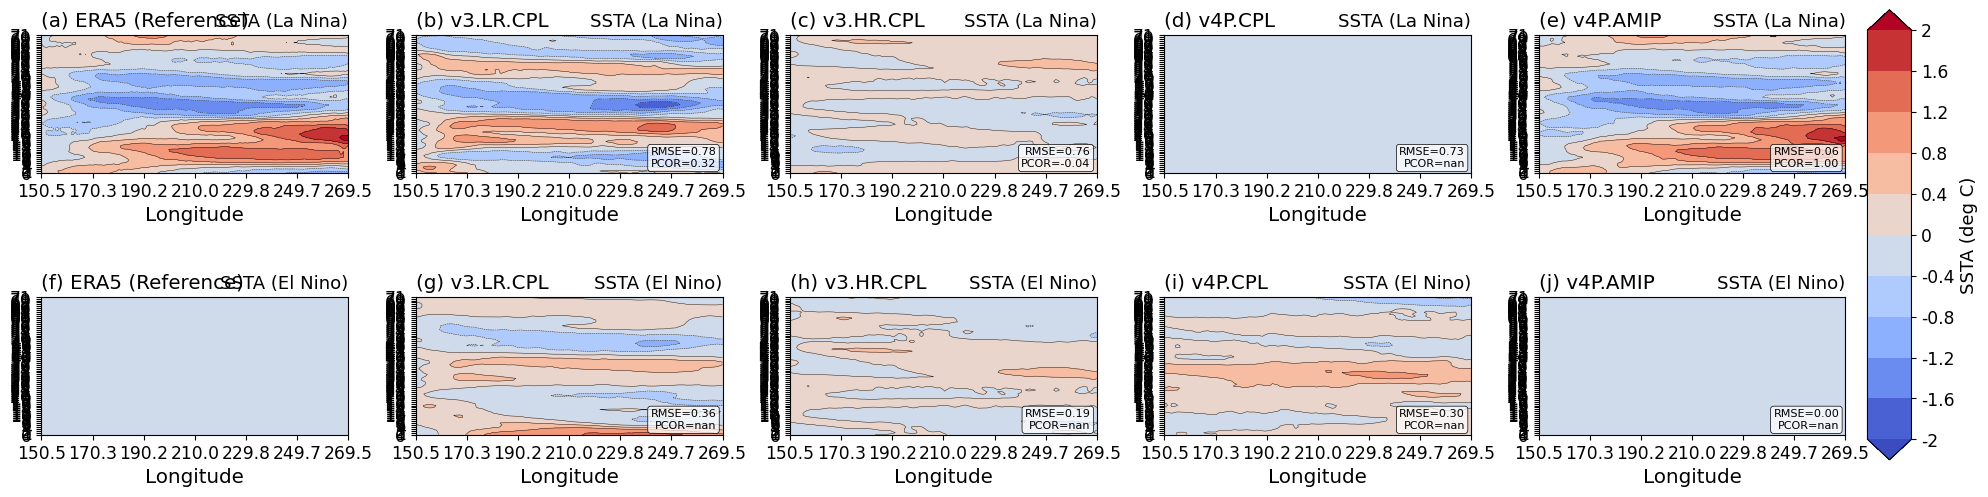

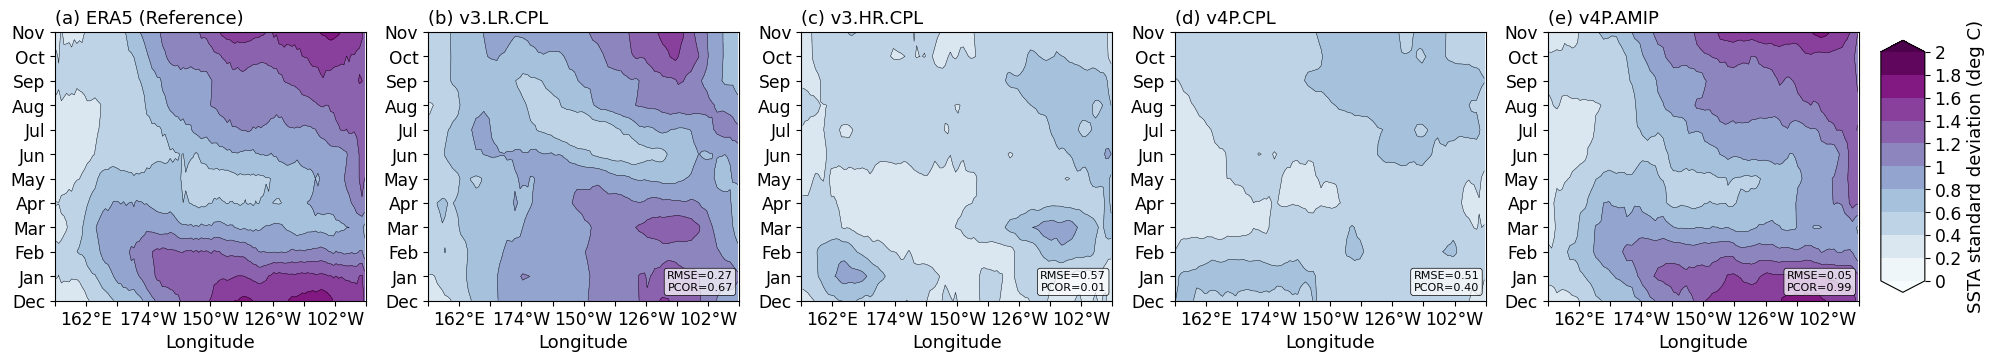

In [3]:
# Four-model ENSO Hovmoller-pattern comparison. This mirrors plot_2d_map.ipynb and plot_enso_pattern_2d.ipynb.
OUTPUT_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/enso_pattern_hov")
RUN_TYPE = "model_vs_obs"
RUN_PLOTS = True
STRICT_PATHS = False

OBS_KEY = "reference"
OBS_LABEL = "ERA5"
OBS_TAG = "ERA5"
LAT_NAME = "months"
LON_NAME = "longitude"
FIGURE_FORMAT = "pdf"
FIGURE_DPI = 300
OVERLAY_SPREAD = False
SPREAD_QUANTILE = 0.75
SPREAD_LEVEL = None

TEST_RUNS = [
    PCMDIRun(
        case="20231209.v3.LR.piControl-spinup.chrysalis",
        model_name="EAMXX-ne256_coupled-test",
        metrics_case_id="v20260531",
        output_name="v3.LR.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis",
        model_name="v3-HR_test6-1",
        metrics_case_id="v20260601",
        output_name="v3.HR.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="20260204.ne256.WCYCLXX1850.SOI",
        model_name="EAMXX-ne256_coupled-test",
        metrics_case_id="v20260601",
        output_name="v4P.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1",
        model_name="EAMXX_test2_1",
        metrics_case_id="v20260531",
        output_name="v4P.AMIP",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
]

GROUP = [run.output_name for run in TEST_RUNS]
PLOT_DICT = {
    OBS_KEY: {"label": f"{OBS_LABEL} (Reference)"},
    **{run.output_name: {"label": run.output_name} for run in TEST_RUNS},
}

TARGET_METRIC_CONFIGS = {
    "enso_sst_ts_rmse": {
        "group": "ENSO_perf",
        "suffix": "EnsoSstTsRmse",
        "vars": ["Nina_sst_hov", "Nino_sst_hov"],
        "vmap": {
            "Nina_sst_hov": "SSTA (La Nina)",
            "Nino_sst_hov": "SSTA (El Nino)",
        },
        "cmap": "coolwarm",
        "levels": np.linspace(-2, 2, 11),
        "figsize": (22, 7.5),
        "fontz": 13,
        "roll_idx": 0,
        "cb_label": "SSTA (deg C)",
    },
    "enso_seasonality": {
        "group": "ENSO_perf",
        "suffix": "EnsoSeasonality",
        "vars": ["sstStd_hov"],
        "vmap": {
            "sstStd_hov": "SSTA standard deviation",
        },
        "cmap": "BuPu",
        "levels": np.linspace(0, 2, 11),
        "figsize": (22, 4.2),
        "fontz": 13,
        "roll_idx": 1,
        "cb_label": "SSTA standard deviation (deg C)",
    },
}


def find_enso_metric_file(run: PCMDIRun, enso_group: str, suffix: str) -> Path:
    enso_dir = run.www / run.case / "pcmdi_diags" / RUN_TYPE / "metrics_data" / "enso_metric" / enso_group
    pattern = f"*_{enso_group}_{run.metrics_case_id}_{run.model_name}_{suffix}.nc"
    matches = sorted(enso_dir.glob(pattern))
    if not matches:
        fallback_pattern = f"*{run.metrics_case_id}*{suffix}.nc"
        matches = sorted(enso_dir.glob(fallback_pattern))
    if not matches:
        message = f"No ENSO metric file found for {run.output_name}: {enso_dir} / {pattern}"
        if STRICT_PATHS:
            raise FileNotFoundError(message)
        print(f"[WARN] {message}")
        return None
    if len(matches) > 1:
        print(f"[WARN] Multiple files matched {run.output_name}; using {matches[-1].name}")
    return matches[-1]


def _pick_data_var(ds: xr.Dataset, base_name: str, tag: str) -> str:
    exact = f"{base_name}__{tag}"
    if exact in ds.data_vars:
        return exact
    matches = [name for name in ds.data_vars if name.startswith(f"{base_name}__") and tag in name]
    if not matches:
        matches = [name for name in ds.data_vars if name.startswith(f"{base_name}__")]
    if not matches:
        raise KeyError(f"Could not find variable for {base_name!r} and tag {tag!r}; available vars: {list(ds.data_vars)}")
    return matches[0]


def load_hov_field(path: Path, base_name: str, tag: str) -> xr.DataArray:
    ds = xr.open_dataset(path, decode_times=False)
    var_name = _pick_data_var(ds, base_name, tag)
    da = ds[var_name].squeeze().load()
    ds.close()

    month_dim = "months" if "months" in da.dims else next(dim for dim in da.dims if "month" in dim.lower())
    lon_dim = "lon" if "lon" in da.dims else next(dim for dim in da.dims if dim != month_dim)
    da = da.rename({month_dim: LAT_NAME, lon_dim: LON_NAME})
    da = da.rename(base_name)
    return da


def build_hov_plotter(target_var: str, files_by_model: dict, config: dict) -> ENSOPatternMapPlotter:
    data_dict = {}
    first_path = next(path for path in files_by_model.values() if path is not None)
    data_dict[OBS_KEY] = load_hov_field(first_path, target_var, OBS_TAG)

    for run in TEST_RUNS:
        path = files_by_model[run.output_name]
        if path is None:
            continue
        data_dict[run.output_name] = load_hov_field(path, target_var, run.model_name)

    for group, da in data_dict.items():
        print(f"  {group}: shape={da.shape} dims={da.dims}")

    return ENSOPatternMapPlotter(
        data_dict=data_dict,
        fig_dir=str(OUTPUT_DIR),
        plot_dict=PLOT_DICT,
        group_order=GROUP,
        obs_key=OBS_KEY,
        lat_name=LAT_NAME,
        lon_name=LON_NAME,
    )


if RUN_PLOTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for target_metric, config in TARGET_METRIC_CONFIGS.items():
    print(f"\n=== {target_metric} ===")
    files_by_model = {
        run.output_name: find_enso_metric_file(run, config["group"], config["suffix"])
        for run in TEST_RUNS
    }
    print("Resolved ENSO Hovmoller files:")
    for name, path in files_by_model.items():
        print(f"  {name}: {path if path else 'MISSING'}")

    if not RUN_PLOTS:
        continue

    plotters = []
    var_labels = []
    for target_var in config["vars"]:
        print(f"\n>>> Loading target_var = {target_var}")
        plotters.append(build_hov_plotter(target_var, files_by_model, config))
        var_labels.append(config["vmap"][target_var])

    if len(plotters) == 1:
        plotters[0].plot_sst_map(
            filename=f"enso_{target_metric}_four_models_hov.pdf",
            figsize=config["figsize"],
            fontz=config["fontz"],
            overlay_spread=OVERLAY_SPREAD,
            spread_quantile=SPREAD_QUANTILE,
            spread_level=SPREAD_LEVEL,
            cmap=config["cmap"],
            mlevels=config["levels"],
            fig_format=FIGURE_FORMAT,
            fig_dpi=FIGURE_DPI,
            roll_idx=config["roll_idx"],
            cb_label=config["cb_label"],
        )
    else:
        plotters[0].plot_multi_sst_map(
            other_plotter=plotters[1],
            var_labels=var_labels,
            filename=f"enso_{target_metric}_four_models_hov.pdf",
            figsize=config["figsize"],
            fontz=config["fontz"],
            overlay_spread=OVERLAY_SPREAD,
            spread_quantile=SPREAD_QUANTILE,
            spread_level=SPREAD_LEVEL,
            cmap=config["cmap"],
            mlevels=config["levels"],
            fig_format=FIGURE_FORMAT,
            fig_dpi=FIGURE_DPI,
            cb_label=config["cb_label"],
        )

if not RUN_PLOTS:
    print("Set RUN_PLOTS = True after checking the resolved ENSO files above.")
